<a href="https://colab.research.google.com/github/hosseinayoubi/Report/blob/main/Patient_No_Show_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
**Applied Analytics & AI Mini Project**

This notebook is the technical part of my project. I kept it simple on purpose.

My question is straightforward: **can appointment data help identify patients who are more likely to miss a scheduled visit?**

I treat **No-show = Yes** as the positive class. The Word report is my main written report, and this notebook shows where the numbers and figures come from.

## 1. Load the data

I use the public **Medical Appointment No Show** dataset from Kaggle.

For Colab, I read the CSV directly from my GitHub repository. I use the `raw.githubusercontent.com` link because pandas needs the file itself, not the normal GitHub preview page.

In [20]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/hosseinayoubi/Report/main/Patient_No_Show-KaggleV2-May-2016.csv"

# Local fallback only helps when I test the notebook outside Colab.
local_files = [
    Path("Patient_No_Show-KaggleV2-May-2016.csv"),
    Path("/mnt/data/KaggleV2-May-2016.csv")
]

local_file = next((p for p in local_files if p.exists()), None)

if local_file is not None:
    raw = pd.read_csv(local_file)
else:
    raw = pd.read_csv(DATA_URL)

print(f"Loaded {len(raw):,} rows")
raw.head()

Loaded 110,527 rows


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## 2. Clean the data

I first check the obvious problems: missing values, exact duplicate rows, impossible ages, and negative waiting time.

I keep age 0 because it can represent infants.

In [21]:
df = raw.copy()

df["ScheduledDay_dt"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay_dt"] = pd.to_datetime(df["AppointmentDay"])

df["waiting_days"] = (
    df["AppointmentDay_dt"].dt.normalize()
    - df["ScheduledDay_dt"].dt.normalize()
).dt.days

quality_check = pd.DataFrame({
    "Check": [
        "Original rows",
        "Missing values",
        "Exact duplicate rows",
        "Age below 0",
        "Negative waiting days"
    ],
    "Result": [
        len(df),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        int((df["Age"] < 0).sum()),
        int((df["waiting_days"] < 0).sum())
    ]
})

quality_check

,Check,Result
0,Original rows,110527
1,Missing values,0
2,Exact duplicate rows,0
3,Age below 0,1
4,Negative waiting days,5


In [22]:
clean = df[(df["Age"] >= 0) & (df["waiting_days"] >= 0)].copy()

clean["no_show"] = (clean["No-show"] == "Yes").astype(int)
clean["appointment_weekday"] = clean["AppointmentDay_dt"].dt.day_name()
clean["scheduled_weekday"] = clean["ScheduledDay_dt"].dt.day_name()
clean["scheduled_hour"] = clean["ScheduledDay_dt"].dt.hour
clean["appointment_month"] = clean["AppointmentDay_dt"].dt.month

print(f"Rows after cleaning: {len(clean):,}")
print(f"Rows removed: {len(raw) - len(clean)}")

Rows after cleaning: 110,521
Rows removed: 6


## 3. Quick look at the target

About one appointment in five is a no-show. This means the classes are not balanced, so accuracy alone is not enough for model evaluation.

In [23]:
class_balance = clean["No-show"].value_counts().rename_axis("Outcome").to_frame("Count")
class_balance["Percent"] = (class_balance["Count"] / len(clean) * 100).round(2)
class_balance

,Count,Percent
Outcome,,
No,88207,79.81
Yes,22314,20.19


## 4. Exploratory analysis

I looked at a few simple patterns before building any model. The most useful one was waiting time.

In [24]:
clean["waiting_group"] = pd.cut(
    clean["waiting_days"],
    bins=[-0.1, 0, 3, 7, 14, 30, 60, np.inf],
    labels=["Same day", "1-3 days", "4-7 days", "8-14 days",
            "15-30 days", "31-60 days", "61+ days"]
)

waiting_table = clean.groupby("waiting_group", observed=False)["no_show"].agg(["count", "mean"])
waiting_table["no_show_rate_percent"] = (waiting_table["mean"] * 100).round(2)
waiting_table[["count", "no_show_rate_percent"]]

,count,no_show_rate_percent
waiting_group,,
Same day,38562,4.65
1-3 days,14675,22.89
4-7 days,17510,25.20
8-14 days,12025,30.47
15-30 days,17371,32.59
31-60 days,8283,34.15
61+ days,2095,28.45


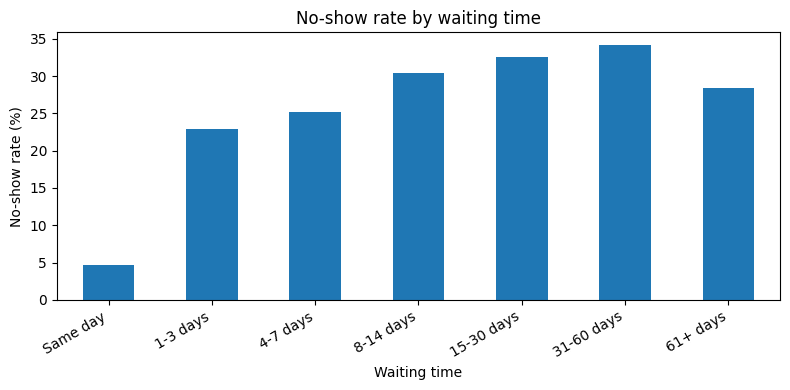

In [25]:
ax = waiting_table["no_show_rate_percent"].plot(
    kind="bar",
    figsize=(8, 4),
    title="No-show rate by waiting time"
)
ax.set_xlabel("Waiting time")
ax.set_ylabel("No-show rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Same-day appointments have a much lower no-show rate. The rate rises as the waiting period gets longer, although the pattern is not perfectly linear.

This is an **association**, not proof that waiting time causes a no-show.

### Age

In [26]:
clean["age_group"] = pd.cut(
    clean["Age"],
    bins=[-0.1, 5, 17, 29, 44, 59, np.inf],
    labels=["0-5", "6-17", "18-29", "30-44", "45-59", "60+"]
)

age_table = clean.groupby("age_group", observed=False)["no_show"].agg(["count", "mean"])
age_table["no_show_rate_percent"] = (age_table["mean"] * 100).round(2)
age_table[["count", "no_show_rate_percent"]]

,count,no_show_rate_percent
age_group,,
0-5,11731,18.63
6-17,15647,24.36
18-29,16729,24.64
30-44,22021,21.82
45-59,23221,17.87
60+,21172,15.31


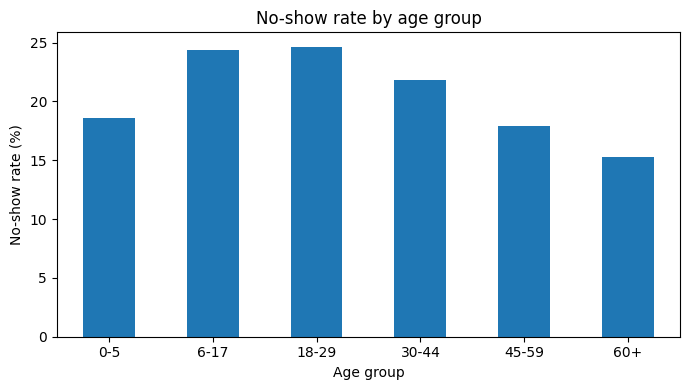

In [27]:
ax = age_table["no_show_rate_percent"].plot(
    kind="bar",
    figsize=(7, 4),
    title="No-show rate by age group"
)
ax.set_xlabel("Age group")
ax.set_ylabel("No-show rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The **18-29** group has the highest no-show rate in this dataset, at about **24.6%**. Ages 6-17 are very close.

### Gender and SMS

In [28]:
gender_table = clean.groupby("Gender")["no_show"].agg(["count", "mean"])
gender_table["no_show_rate_percent"] = (gender_table["mean"] * 100).round(2)

sms_table = clean.groupby("SMS_received")["no_show"].agg(["count", "mean"])
sms_table["no_show_rate_percent"] = (sms_table["mean"] * 100).round(2)

print("Gender")
display(gender_table[["count", "no_show_rate_percent"]])

print("SMS received")
display(sms_table[["count", "no_show_rate_percent"]])

Gender


,count,no_show_rate_percent
Gender,,
F,71836,20.31
M,38685,19.96


SMS received


,count,no_show_rate_percent
SMS_received,,
0,75039,16.70
1,35482,27.57


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


Gender shows only a small difference.

The SMS result is more interesting: patients who received an SMS have a higher observed no-show rate. I do **not** read this as evidence that SMS messages cause no-shows. The reminders were probably not assigned randomly.

## 5. Build the models

I use a **70/30 split by PatientId**. This keeps the same patient from appearing in both training and test data.

I leave `PatientId` and `AppointmentID` out of the model. I also leave `Neighbourhood` out because location can act as a proxy for social or geographic factors.

I compare four models:
- Dummy baseline
- Logistic Regression
- Decision Tree
- Random Forest

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

features = [
    "Gender", "Age", "Scholarship", "Hipertension", "Diabetes",
    "Alcoholism", "Handcap", "SMS_received", "waiting_days",
    "scheduled_hour", "appointment_weekday",
    "scheduled_weekday", "appointment_month"
]

X = clean[features]
y = clean["no_show"]
groups = clean["PatientId"]

split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 77,565
Test rows:  32,956


In [11]:
numeric_features = [
    "Age", "Scholarship", "Hipertension", "Diabetes",
    "Alcoholism", "Handcap", "SMS_received",
    "waiting_days", "scheduled_hour", "appointment_month"
]

categorical_features = [
    "Gender", "appointment_weekday", "scheduled_weekday"
]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("fill", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("fill", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        solver="liblinear", random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=100,
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, max_depth=10, min_samples_leaf=50,
        class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    )
}

In [12]:
results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, pred)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_no_show": precision_score(y_test, pred, zero_division=0),
        "recall_no_show": recall_score(y_test, pred, zero_division=0),
        "f1_no_show": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1]
    })

    fitted[name] = (pipe, pred, prob)

metrics = pd.DataFrame(results)
metrics.round(3)

,model,accuracy,precision_no_show,recall_no_show,f1_no_show,roc_auc,tn,fp,fn,tp
0,Dummy baseline,0.796,0.000,0.000,0.000,0.500,26221,0,6735,0
1,Logistic Regression,0.663,0.320,0.574,0.410,0.669,17990,8231,2870,3865
2,Decision Tree,0.573,0.303,0.835,0.444,0.725,13271,12950,1113,5622
3,Random Forest,0.573,0.304,0.845,0.447,0.728,13201,13020,1043,5692


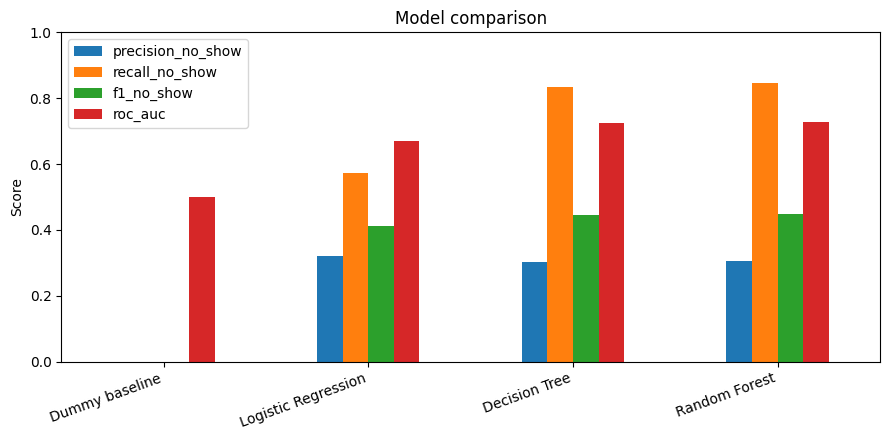

In [13]:
plot_metrics = (
    metrics.set_index("model")[["precision_no_show", "recall_no_show", "f1_no_show", "roc_auc"]]
)

ax = plot_metrics.plot(kind="bar", figsize=(9, 4.5))
ax.set_title("Model comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The dummy baseline gets high accuracy because it predicts the majority class every time. It finds **zero** no-shows.

The Random Forest gives the best F1 score in this run. Recall is high, but precision is much lower. In practical terms, it catches many no-shows but also creates many false alarms.

## 6. Confusion matrix

In [14]:
best_name = metrics.loc[metrics["f1_no_show"].idxmax(), "model"]
best_pipe, best_pred, best_prob = fitted[best_name]

cm = confusion_matrix(y_test, best_pred)

print("Best model by no-show F1:", best_name)
print(pd.DataFrame(
    cm,
    index=["Actual show", "Actual no-show"],
    columns=["Predicted show", "Predicted no-show"]
))

Best model by no-show F1: Random Forest
                Predicted show  Predicted no-show
Actual show              13201              13020
Actual no-show            1043               5692


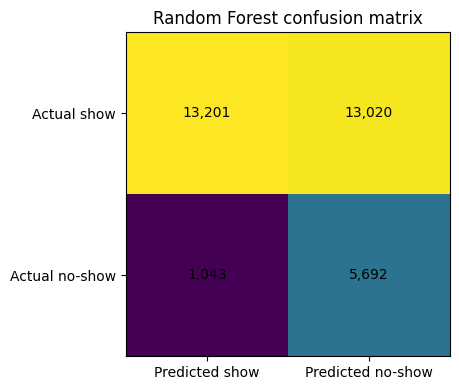

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks([0, 1], ["Predicted show", "Predicted no-show"])
ax.set_yticks([0, 1], ["Actual show", "Actual no-show"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

ax.set_title(f"{best_name} confusion matrix")
plt.tight_layout()
plt.show()

At the default 0.50 threshold, the Random Forest finds most actual no-shows, but it also flags many appointments that would have been attended.

For reminders, that trade-off may be acceptable. For decisions that affect access to care, it would not be.

## 7. Feature importance

In [16]:
rf_pipe = fitted["Random Forest"][0]

feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importance = rf_pipe.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .head(10)
)

feature_importance

,feature,importance
7,num__waiting_days,0.692815
0,num__Age,0.079240
6,num__SMS_received,0.064756
8,num__scheduled_hour,0.037186
22,cat__scheduled_weekday_Tuesday,0.011485
18,cat__scheduled_weekday_Friday,0.011168
23,cat__scheduled_weekday_Wednesday,0.010753
2,num__Hipertension,0.010037
13,cat__appointment_weekday_Monday,0.009755
9,num__appointment_month,0.009514


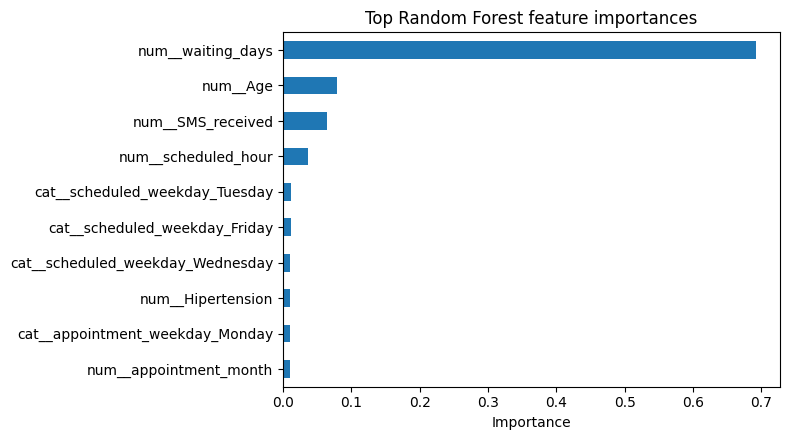

In [17]:
plot_importance = feature_importance.sort_values("importance")

ax = plot_importance.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 4.5),
    legend=False,
    title="Top Random Forest feature importances"
)
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Waiting days is the strongest feature in the Random Forest. SMS status, age, and scheduled hour also matter to the model.

Feature importance tells me what the model used. It does **not** prove that these variables cause a patient to miss an appointment.

## 8. Threshold check

In [18]:
threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60]:
    pred_t = (best_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "flagged_percent": pred_t.mean() * 100
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table.round(3)

,threshold,precision,recall,f1,flagged_percent
0,0.3,0.287,0.932,0.439,66.249
1,0.4,0.288,0.921,0.439,65.272
2,0.5,0.304,0.845,0.447,56.779
3,0.6,0.353,0.521,0.421,30.216


Changing the threshold changes the business trade-off. A lower threshold catches more potential no-shows but sends more reminders. A higher threshold reduces false alarms but misses more no-shows.

## 9. Simple fairness check

In [19]:
test_check = clean.iloc[test_idx][["Gender", "Age"]].copy()
test_check["actual"] = y_test.values
test_check["predicted"] = best_pred

test_check["age_group"] = pd.cut(
    test_check["Age"],
    bins=[-0.1, 5, 17, 29, 44, 59, np.inf],
    labels=["0-5", "6-17", "18-29", "30-44", "45-59", "60+"]
)

fairness_rows = []

for column in ["Gender", "age_group"]:
    for group_name, group in test_check.groupby(column, observed=False):
        fairness_rows.append({
            "group_type": column,
            "group": str(group_name),
            "rows": len(group),
            "actual_no_shows": int(group["actual"].sum()),
            "recall": recall_score(
                group["actual"],
                group["predicted"],
                zero_division=0
            )
        })

fairness_table = pd.DataFrame(fairness_rows)
fairness_table.round(3)

,group_type,group,rows,actual_no_shows,recall
0,Gender,F,21494,4409,0.856
1,Gender,M,11462,2326,0.824
2,age_group,0-5,3478,650,0.942
3,age_group,6-17,4763,1184,0.823
4,age_group,18-29,4862,1191,0.927
5,age_group,30-44,6488,1421,0.942
6,age_group,45-59,7013,1287,0.830
7,age_group,60+,6352,1002,0.593


Recall is not identical across groups, especially across age groups. That does not automatically mean the model is unfair, but it is a warning sign.

If this were used in real healthcare, I would monitor subgroup performance and check whether the intervention creates unequal treatment.

## 10. Responsible use

I would keep the use case narrow.

Good uses:
- extra reminders
- confirmation messages
- easier rescheduling

I would **not** use this model to cancel appointments, deprioritize patients, or reduce access automatically.

Real healthcare data would also need strong privacy controls, limited access, and proper anonymization or pseudonymization.

## 11. Limitations and next step

This is one historical public dataset. I would not assume the same numbers apply to a Finnish hospital or to current patients.

The analysis is observational, so it shows patterns and associations, not causal effects.

My next step in a real project would be:
1. test the workflow on newer local data,
2. choose the threshold using the real cost of reminders and missed appointments,
3. monitor performance over time,
4. repeat the subgroup checks after deployment.

## 12. Short takeaway

Waiting time was the clearest practical signal.

The Random Forest catches a large share of actual no-shows, but precision is limited. For that reason, I see the model as a **support tool for reminders and scheduling**, not as an automatic decision system.

## AI use note

I used AI tools for coding support and language editing. I reviewed the workflow, reran the notebook, and checked the reported values against the notebook output. I kept the analysis choices and interpretation simple enough that I can explain them during the presentation.

## References

- Kaggle, *Medical Appointment No Shows* dataset: https://www.kaggle.com/datasets/joniarroba/noshowappointments
- Metropolia University of Applied Sciences, *Applied Analytics & AI* course materials, 2026.